# Uczenie Maszynowe – Laboratorium 3: Klasyfikacja
### Zbiór danych: Heart Disease Cleveland

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report
)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

---
# Zadanie 1 – Wczytanie i eksploracja zbioru danych

In [3]:
# 1.1 Wczytuję dane i sprawdzam podstawową strukturę
df = pd.read_csv('Heart_disease_cleveland_new.csv')
print(f'Rozmiar: {df.shape[0]} pacjentów, {df.shape[1]} kolumn')
df.head()

Rozmiar: 303 pacjentów, 14 kolumn


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [4]:
# 1.2 Opisuję kolumny i określam typy zmiennych
opisy = {
    'age':      ('Wiek pacjenta (lata)',                                             'ciagla'),
    'sex':      ('Plec: 1=mezczyzna, 0=kobieta',                                    'binarna'),
    'cp':       ('Typ bolu w klatce: 0-3',                                          'kategoryczna'),
    'trestbps': ('Cisnienie krwi w spoczynku (mmHg)',                               'ciagla'),
    'chol':     ('Poziom cholesterolu (mg/dl)',                                     'ciagla'),
    'fbs':      ('Cukier na czczo > 120 mg/dl: 1=tak, 0=nie',                      'binarna'),
    'restecg':  ('Wynik EKG w spoczynku: 0-2',                                     'kategoryczna'),
    'thalach':  ('Maksymalne tetno (uderzen/min)',                                  'ciagla'),
    'exang':    ('Dusznica wywolana wysilkiem: 1=tak, 0=nie',                       'binarna'),
    'oldpeak':  ('Obnizenie odcinka ST po wysilku',                                'ciagla'),
    'slope':    ('Nachylenie ST: 0=opadajace, 1=plaskie, 2=rosnace',               'kategoryczna'),
    'ca':       ('Liczba glownych naczyn (0-3)',                                    'porzadkowa'),
    'thal':     ('Test obciazeniowy: 1=normalny, 2=utrwalony, 3=odwracalny defekt', 'kategoryczna'),
    'target':   ('ETYKIETA: 1=choroba serca, 0=brak choroby',                      'cel klasyfikacji'),
}
pd.DataFrame(opisy, index=['Opis', 'Typ']).T

,Opis,Typ
age,Wiek pacjenta (lata),ciagla
sex,"Plec: 1=mezczyzna, 0=kobieta",binarna
cp,Typ bolu w klatce: 0-3,kategoryczna
trestbps,Cisnienie krwi w spoczynku (mmHg),ciagla
chol,Poziom cholesterolu (mg/dl),ciagla
fbs,"Cukier na czczo > 120 mg/dl: 1=tak, 0=nie",binarna
restecg,Wynik EKG w spoczynku: 0-2,kategoryczna
thalach,Maksymalne tetno (uderzen/min),ciagla
exang,"Dusznica wywolana wysilkiem: 1=tak, 0=nie",binarna
oldpeak,Obnizenie odcinka ST po wysilku,ciagla


In [ ]:
# 1.3 Sprawdzam czy sa brakujace wartosci
print('Brakujace wartosci na kolumne:')
print(df.isnull().sum())
print(f'\nLacznie brakujacych: {df.isnull().sum().sum()}')

# WNIOSEK: brak wartosci NaN – dane sa kompletne, nie trzeba nic uzupelniac.

Brakujace wartosci na kolumne:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Lacznie brakujacych: 0


In [5]:
# 1.4 Statystyki opisowe
df.describe().round(2)

# WNIOSEK: cechy maja bardzo rozne skale – chol (~246), trestbps (~131), fbs (0 lub 1).
# To sygnal, ze skalowanie bedzie mialo znaczenie dla modelu.

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.44,0.68,2.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,0.60,0.66,1.83,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.93,0.96,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,1.00,0.00
25%,48.00,0.00,2.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,0.00,0.00,1.00,0.00
50%,56.00,1.00,2.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,1.00,0.00
75%,61.00,1.00,3.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,1.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,3.00,3.00,1.00


In [6]:
# 1.5 Sprawdzam rozkład klas – czy mam zbalansowany dataset
n_zdrowych = (df['target'] == 0).sum()
n_chorych  = (df['target'] == 1).sum()
n_total    = len(df)

print('=== Rozklad klas ===')
print(f'Lacznie pacjentow:  {n_total}')
print(f'Zdrowi  (klasa 0):  {n_zdrowych}  ({n_zdrowych/n_total*100:.1f}%)')
print(f'Chorzy  (klasa 1):  {n_chorych}   ({n_chorych/n_total*100:.1f}%)')

# WNIOSEK: klasy prawie rownoliczne (54% vs 46%), stosunek 1.18:1.
# Nie ma problemu z balansem – standardowe metryki beda miarodajne.

=== Rozklad klas ===
Lacznie pacjentow:  303
Zdrowi  (klasa 0):  164  (54.1%)
Chorzy  (klasa 1):  139   (45.9%)


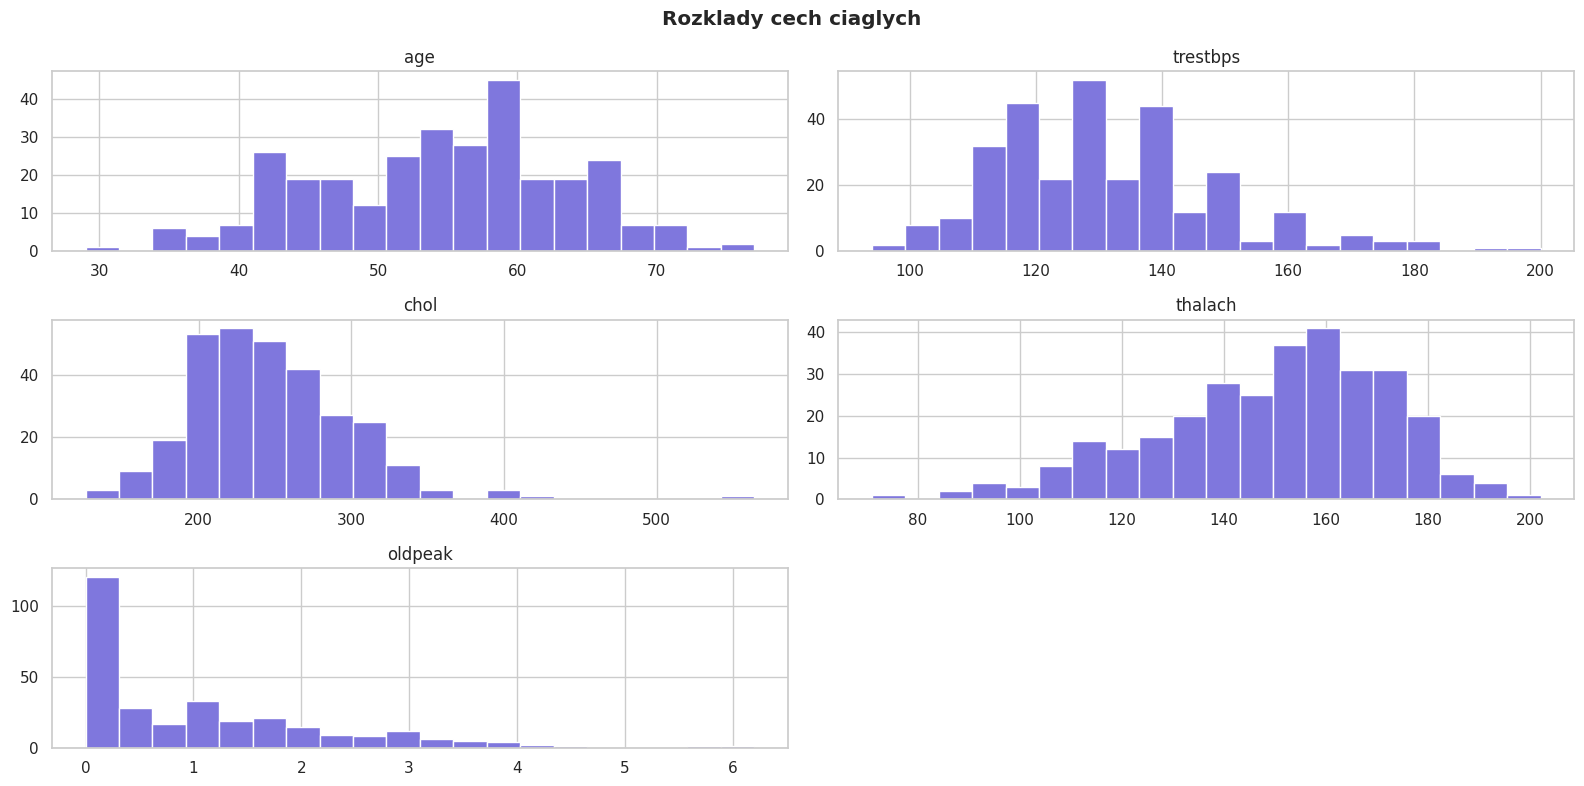

In [7]:
# 1.6 Rozkłady cech ciągłych – sprawdzam skosnosc danych
cechy_ciagle = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[cechy_ciagle].hist(bins=20, figsize=(16, 8), color='#7F77DD', edgecolor='white')
plt.suptitle('Rozklady cech ciaglych', fontweight='bold')
plt.tight_layout()
plt.show()

# WNIOSEK: wiekszos cech ma rozklad zblizony do normalnego.
# Wyjątek: oldpeak jest mocno prawostronnie skosny (wielu pacjentow ma wartosc 0).
# Skosnosc jest umiarkowana – nie wymaga transformacji logarytmicznej przed skalowaniem.

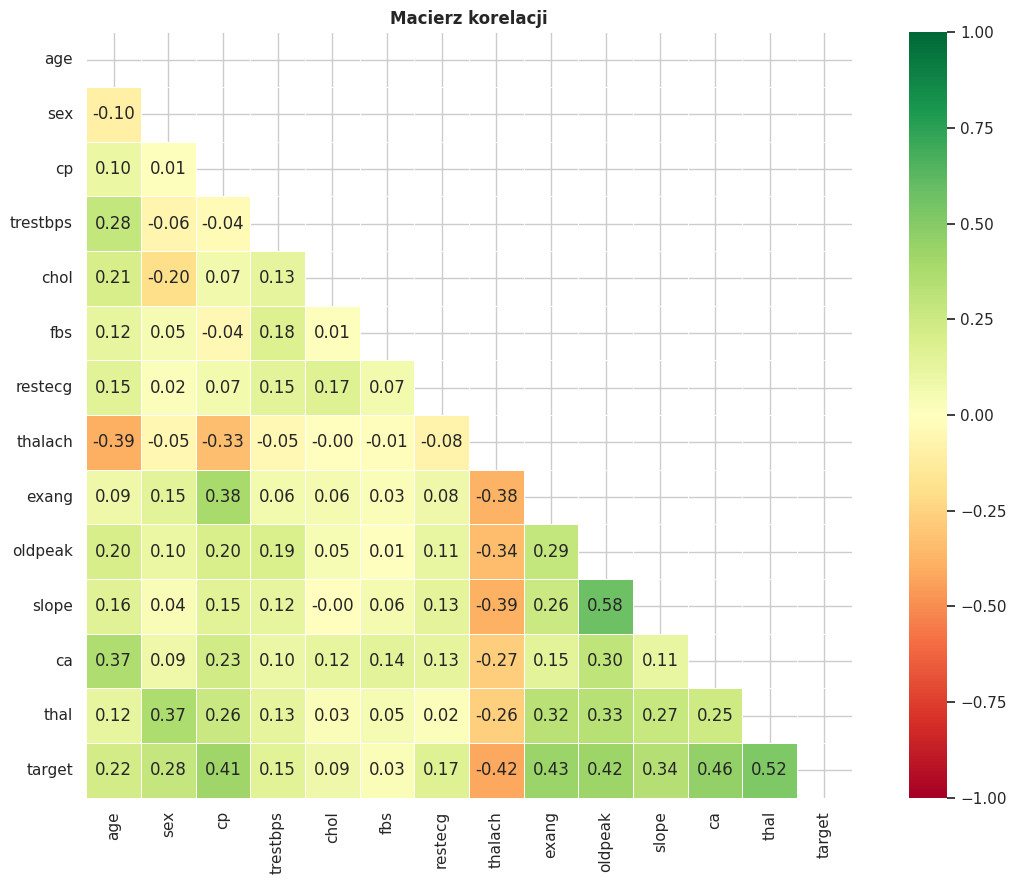

In [8]:
# 1.7 Macierz korelacji – zaleznosci miedzy cechami i targetem
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, mask=mask, square=True, linewidths=0.5)
plt.title('Macierz korelacji', fontweight='bold')
plt.tight_layout()
plt.show()


# WNIOSEK: najsilniej skorelowane z choroба: cp (+0.43), exang (-0.44),
# thalach (-0.42), oldpeak (-0.43), ca (-0.40).
# Cechy fbs i chol maja slaba korelacje – mala wartosc predykcyjna.
# Brak silnych korelacji miedzy samymi cechami – multikoliniarnos nie jest problemem.

---
# Zadanie 2 – Przygotowanie danych i trening klasyfikatora

In [9]:
# 2.1 Dziele dane na cechy (X) i etykiety (y)
X = df.drop('target', axis=1)
y = df['target']
print(f'X: {X.shape}, y: {y.shape}')

X: (303, 13), y: (303,)


In [10]:
# 2.2 Dziele na zbior treningowy i testowy
# stratify=y zapewnia taki sam rozklad klas w obu zbiorach
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Trening: {X_train.shape[0]} probek  ({(y_train==1).mean()*100:.1f}% chorych)')
print(f'Test:    {X_test.shape[0]} probek   ({(y_test==1).mean()*100:.1f}% chorych)')

# WNIOSEK: stratyfikacja zadzialala – oba podzbiory maja ~46% chorych.
# Poddzial 80/20: 242 probki treningowe, 61 testowych.

Trening: 242 probek  (45.9% chorych)
Test:    61 probek   (45.9% chorych)


In [11]:
# 2.3 Trenuję model regresji logistycznej na surowych danych
model_bazowy = LogisticRegression(class_weight='balanced',max_iter=10000, random_state=RANDOM_STATE)
model_bazowy.fit(X_train, y_train)
y_pred_bazowy = model_bazowy.predict(X_test)

print(f'Accuracy trening: {model_bazowy.score(X_train, y_train)*100:.1f}%')
print(f'Accuracy test:    {model_bazowy.score(X_test, y_test)*100:.1f}%')

# WNIOSEK: model dziala. Mala roznica trening/test sugeruje brak overfittingu.
# Dokladne metryki ocenimy w zadaniu 3.

Accuracy trening: 85.1%
Accuracy test:    86.9%


---
# Zadanie 3 – Ocena modelu

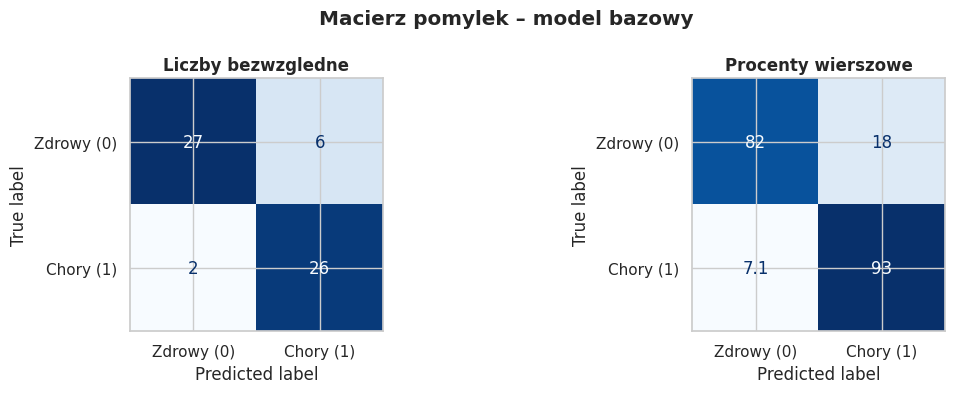

TP=26  TN=27  FP=6  FN=2


In [12]:
# 3.1 Macierz pomylek
cm = confusion_matrix(y_test, y_pred_bazowy)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(cm, display_labels=['Zdrowy (0)', 'Chory (1)']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Liczby bezwzgledne', fontweight='bold')

cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
ConfusionMatrixDisplay(cm_pct.round(1), display_labels=['Zdrowy (0)', 'Chory (1)']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Procenty wierszowe', fontweight='bold')
plt.suptitle('Macierz pomylek – model bazowy', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'TP={tp}  TN={tn}  FP={fp}  FN={fn}')

# WNIOSEK: model ma wiecej bledow FN (chorzy uznani za zdrowych) niz FP.
# W diagnostyce medycznej FN jest grozniejszy – chorzy nie dostaja pomocy.
# Recall bedzie wazniejsza metryka niz Precision.

In [13]:
# 3.2 Metryki klasyfikacji
acc  = accuracy_score(y_test, y_pred_bazowy)
prec = precision_score(y_test, y_pred_bazowy)
rec  = recall_score(y_test, y_pred_bazowy)
f1   = f1_score(y_test, y_pred_bazowy)

print('Metryki modelu bazowego:')
print(f'  Accuracy  (dokladnosc):  {acc:.4f}')
print(f'  Precision (precyzja):    {prec:.4f}')
print(f'  Recall    (czulosc):     {rec:.4f}')
print(f'  F1-Score:                {f1:.4f}')
print()
print(classification_report(y_test, y_pred_bazowy, target_names=['Zdrowy', 'Chory']))

# WNIOSEK:
# Model ma rację w 81% gdy mówi "chory" (Precision=0.81),
# ale 7% chorych przeoczył (FN) – Recall=0.93.
# W zastosowaniach medycznych warto rozwazyc nizszy prog decyzyjny
# zeby zmniejszyc FN kosztem wiekszej liczby FP.

Metryki modelu bazowego:
  Accuracy  (dokladnosc):  0.8689
  Precision (precyzja):    0.8125
  Recall    (czulosc):     0.9286
  F1-Score:                0.8667

              precision    recall  f1-score   support

      Zdrowy       0.93      0.82      0.87        33
       Chory       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



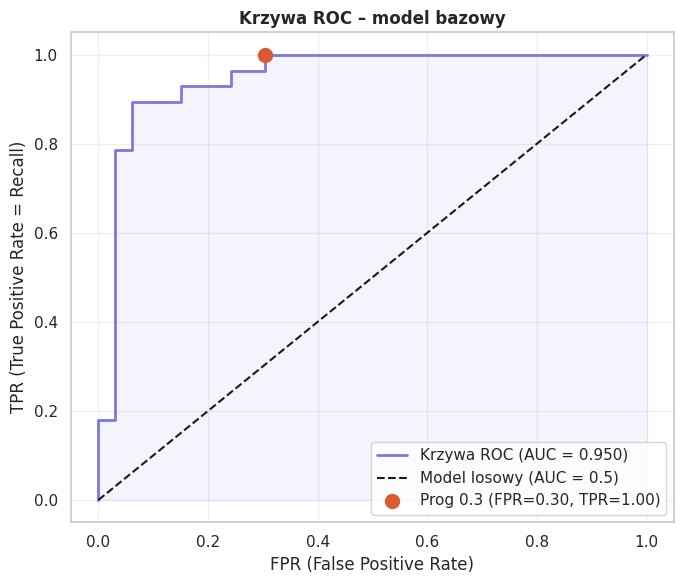

AUC = 0.9502


In [14]:
# 3.3 Krzywa ROC
y_prob = model_bazowy.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#7F77DD', lw=2, label=f'Krzywa ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Model losowy (AUC = 0.5)')
idx = np.argmin(np.abs(thresholds - 0.3))
plt.scatter(fpr[idx], tpr[idx], color='#D85A30', s=100, zorder=5,label=f'Prog 0.3 (FPR={fpr[idx]:.2f}, TPR={tpr[idx]:.2f})')
plt.fill_between(fpr, tpr, alpha=0.08, color='#7F77DD')
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate = Recall)')
plt.title('Krzywa ROC – model bazowy', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC = {auc:.4f}')

# WNIOSEK: AUC powyzej 0.8 to dobry wynik – model wyraznie lepszy od losowego.
# Punkt na wykresie pokazuje gdzie jestesmy przy domyslnym progu 0.5.
# Przesuwajac prog w lewo zwiekszyliby Recall kosztem wyzszego FPR.

---
# Zadanie 4a – Wpływ skalowania danych

In [15]:
# 4.1 Stosuje dwie metody skalowania
# fit() tylko na danych treningowych, transform() na obu zbiorach
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std  = scaler_std.transform(X_test)

scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm  = scaler_mm.transform(X_test)

chol_idx = list(X.columns).index('chol')
print('Weryfikacja skalowania (cecha chol):')
print(f'  StandardScaler – mean={X_train_std[:,chol_idx].mean():.3f}, std={X_train_std[:,chol_idx].std():.3f}')
print(f'  MinMaxScaler   – min={X_train_mm[:,chol_idx].min():.3f}, max={X_train_mm[:,chol_idx].max():.3f}')

Weryfikacja skalowania (cecha chol):
  StandardScaler – mean=0.000, std=1.000
  MinMaxScaler   – min=0.000, max=1.000


                Accuracy  Precision  Recall      F1     AUC
Model                                                      
Bez skalowania    0.8689     0.8125  0.9286  0.8667  0.9524
StandardScaler    0.8689     0.8125  0.9286  0.8667  0.9535
MinMaxScaler      0.8525     0.8065  0.8929  0.8475  0.9426


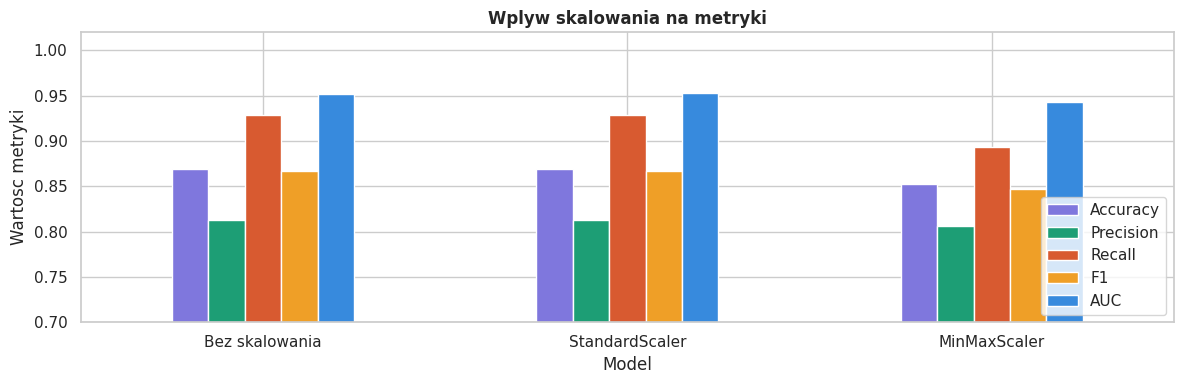

In [16]:
# 4.2 Porownuje trzy wersje modelu: bez skalowania, StandardScaler, MinMaxScaler
def trenuj_i_ocen(X_tr, X_te, y_tr, y_te, nazwa):
    m = LogisticRegression(max_iter=100000, random_state=RANDOM_STATE)
    m.fit(X_tr, y_tr)
    y_pred = m.predict(X_te)
    y_prob = m.predict_proba(X_te)[:, 1]

    return {
        'Model':     nazwa,
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall':    round(recall_score(y_te, y_pred), 4),
        'F1':        round(f1_score(y_te, y_pred), 4),
        'AUC':       round(roc_auc_score(y_te, y_prob), 4),
    }

wyniki = pd.DataFrame([
    trenuj_i_ocen(X_train,     X_test,     y_train, y_test, 'Bez skalowania'),
    trenuj_i_ocen(X_train_std, X_test_std, y_train, y_test, 'StandardScaler'),
    trenuj_i_ocen(X_train_mm,  X_test_mm,  y_train, y_test, 'MinMaxScaler'),]).set_index('Model')

print(wyniki)

wyniki.plot(kind='bar', figsize=(12, 4), ylim=(0.70, 1.02), edgecolor='white',
            color=['#7F77DD','#1D9E75','#D85A30','#EF9F27','#378ADD'])
plt.title('Wplyw skalowania na metryki', fontweight='bold')
plt.ylabel('Wartosc metryki')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# WNIOSEK: StandardScaler nieznacznie poprawia metryki wzgledem braku skalowania.
# MinMaxScaler daje podobne wyniki.
# Roznice sa małe bo dataset nie ma ekstremalnych wartosci odstajacych.
# Dalej bede używał StandardScaler.

---
# Zadanie 5 – Wpływ hiperparametrów

In [17]:
# 5.1 Testuje rozne wartosci C (sila regularyzacji)
wartosci_C = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
wyniki_C = []

for C in wartosci_C:
    m = LogisticRegression(C=C, max_iter=3000, random_state=RANDOM_STATE)
    m.fit(X_train_std, y_train)
    y_pred = m.predict(X_test_std)
    y_prob = m.predict_proba(X_test_std)[:, 1]
    wyniki_C.append({
        'C':          C,
        'Accuracy':   round(accuracy_score(y_test, y_pred), 4),
        'Recall':     round(recall_score(y_test, y_pred), 4),
        'F1':         round(f1_score(y_test, y_pred), 4),
        'AUC':        round(roc_auc_score(y_test, y_prob), 4),
        'train_acc':  round(m.score(X_train_std, y_train), 4),
        'n_iter':     m.n_iter_[0]
    })
df_C = pd.DataFrame(wyniki_C)
print(df_C[['C','Accuracy','Recall','F1','AUC','n_iter']].to_string(index=False))

      C  Accuracy  Recall     F1    AUC  n_iter
  0.001    0.8689  0.7500 0.8400 0.9654       7
  0.010    0.8852  0.8929 0.8772 0.9589       8
  0.100    0.8689  0.9286 0.8667 0.9578       7
  0.500    0.8689  0.9286 0.8667 0.9524       9
  1.000    0.8689  0.9286 0.8667 0.9535       9
  5.000    0.8689  0.9286 0.8667 0.9502      10
 10.000    0.8689  0.9286 0.8667 0.9491      11
 50.000    0.8689  0.9286 0.8667 0.9491      11
100.000    0.8689  0.9286 0.8667 0.9502      11


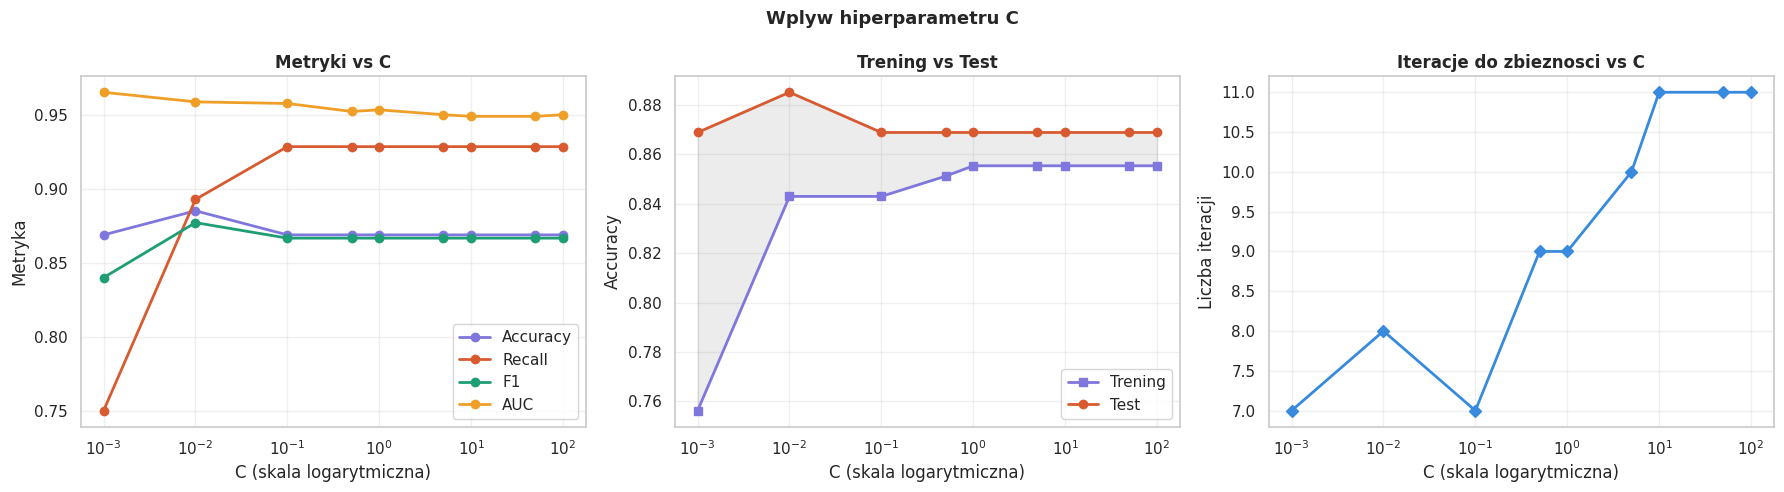

In [18]:
# 5.2 Wizualizacja wplywu C
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for col, color in [('Accuracy','#7F77DD'),('Recall','#D85A30'),('F1','#1D9E75'),('AUC','#EF9F27')]:
    ax.semilogx(df_C['C'], df_C[col], marker='o', label=col, color=color, lw=2)
ax.set_xlabel('C (skala logarytmiczna)')
ax.set_ylabel('Metryka')
ax.set_title('Metryki vs C', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogx(df_C['C'], df_C['train_acc'], marker='s', label='Trening', color='#7F77DD', lw=2)
ax.semilogx(df_C['C'], df_C['Accuracy'],  marker='o', label='Test',    color='#D85A30', lw=2)
ax.fill_between(df_C['C'], df_C['train_acc'], df_C['Accuracy'], alpha=0.15, color='gray')
ax.set_xlabel('C (skala logarytmiczna)')
ax.set_ylabel('Accuracy')
ax.set_title('Trening vs Test', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.semilogx(df_C['C'], df_C['n_iter'], marker='D', color='#378ADD', lw=2)
ax.set_xlabel('C (skala logarytmiczna)')
ax.set_ylabel('Liczba iteracji')
ax.set_title('Iteracje do zbieznosci vs C', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Wplyw hiperparametru C', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# WNIOSEK:
# Male C (0.001-0.01): silna regularyzacja – model jest mocno 'sciskany',
#   Recall spada do ~0.75 bo model jest zbyt ostrozny w klasyfikacji chorych.
#   AUC pozostaje wysokie (~0.96) – model rankinguje poprawnie, ale
#   przy progu 0.5 gorzej klasyfikuje.
# Duze C (50-100): brak regularyzacji – na tym malym datasecie overfitting
#   nie jest wyraznie widoczny, trening i test sa zblizone.
# Optymalne C: okolice 0.1-1.0, gdzie metryki sie stabilizuja.
# Iteracje: rosna wraz z C – przy duzym C solver wykonuje wiecej krokow
#   zanim znajdzie minimum bez 'pomocy' regularyzacji.

In [19]:
# 5.3 Testuje wplyw l1_ratio (ElasticNet – kombinacja L1 i L2)
l1_ratios = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0]
wyniki_enet = []

for l1r in l1_ratios:
    m = LogisticRegression(
        penalty='elasticnet', solver='saga',
        l1_ratio=l1r, C=1.0, max_iter=5000, random_state=RANDOM_STATE)

    m.fit(X_train_std, y_train)
    y_pred = m.predict(X_test_std)
    y_prob = m.predict_proba(X_test_std)[:, 1]
    wyniki_enet.append({
        'l1_ratio':    l1r,
        'Accuracy':    round(accuracy_score(y_test, y_pred), 4),
        'Recall':      round(recall_score(y_test, y_pred), 4),
        'F1':          round(f1_score(y_test, y_pred), 4),
        'AUC':         round(roc_auc_score(y_test, y_prob), 4),
        'zerowe_wagi': int(np.sum(np.abs(m.coef_[0]) < 1e-4)),
        'n_iter':      m.n_iter_[0]
    })

df_enet = pd.DataFrame(wyniki_enet)
print(df_enet.to_string(index=False))

# WNIOSEK: metryki stabilne dla l1_ratio 0.0-0.5.
# Przy l1_ratio=1.0 (czyste L1) rosnie liczba zerowych wag – model
# sam "wylacza" malo istotne cechy (efekt selekcji cech).
# L1 wymaga znacznie wiecej iteracji do zbieznosci niz L2.

 l1_ratio  Accuracy  Recall     F1    AUC  zerowe_wagi  n_iter
      0.0    0.8689  0.9286 0.8667 0.9535            0      21
      0.1    0.8689  0.9286 0.8667 0.9513            0      21
      0.2    0.8689  0.9286 0.8667 0.9502            0      21
      0.3    0.8689  0.9286 0.8667 0.9502            0      21
      0.5    0.8689  0.9286 0.8667 0.9491            0      21
      0.7    0.8689  0.9286 0.8667 0.9481            0      21
      0.9    0.8689  0.9286 0.8667 0.9470            0      21
      1.0    0.8689  0.9286 0.8667 0.9470            0      21


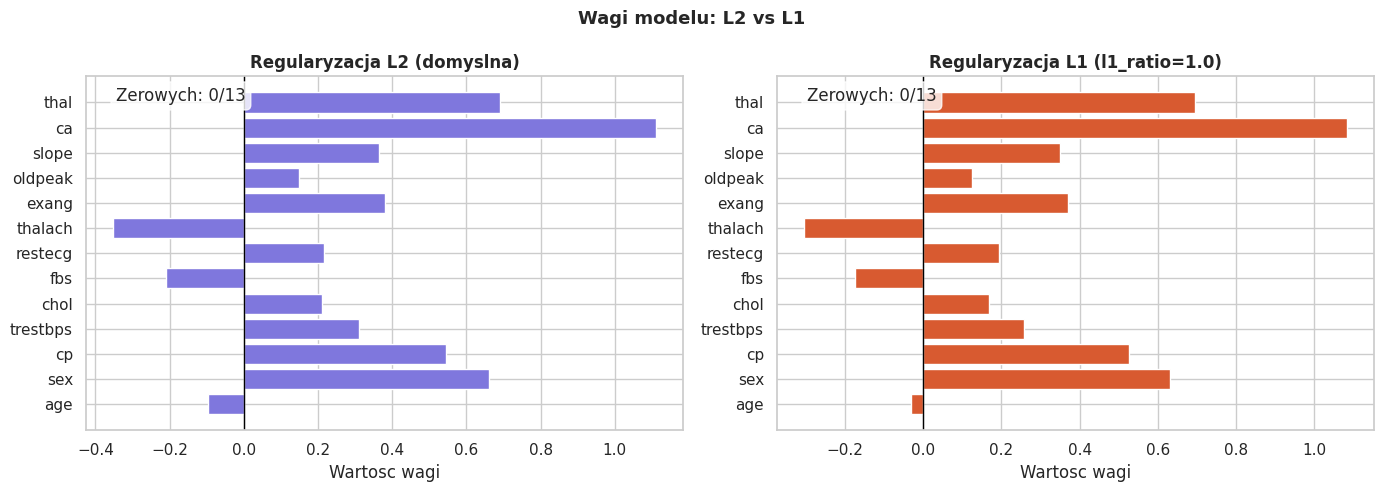

In [20]:
# 5.4 Porownanie wag: L2 vs L1
m_l2 = LogisticRegression(penalty='l2', C=1.0, max_iter=5000, random_state=RANDOM_STATE)
m_l1 = LogisticRegression(penalty='elasticnet', solver='saga',l1_ratio=1.0, C=1.0, max_iter=5000, random_state=RANDOM_STATE)
m_l2.fit(X_train_std, y_train)
m_l1.fit(X_train_std, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, title, color in [(axes[0], m_l2, 'Regularyzacja L2 (domyslna)', '#7F77DD'),(axes[1], m_l1, 'Regularyzacja L1 (l1_ratio=1.0)', '#D85A30')]:
    coefs = model.coef_[0]
    ax.barh(X.columns, coefs, color=[color if abs(c) > 1e-4 else '#D3D1C7' for c in coefs])
    ax.axvline(0, color='black', lw=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Wartosc wagi')
    n_z = int(np.sum(np.abs(coefs) < 1e-4))

    ax.text(0.05, 0.97, f'Zerowych: {n_z}/{len(coefs)}',
            transform=ax.transAxes, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


plt.suptitle('Wagi modelu: L2 vs L1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# WNIOSEK:
# L2 (lewy): wszystkie 13 wag niezerowe, rozlozone rowno – regularyzacja
#   ogranicza ich wielkosc ale zadnej nie eliminuje.
# L1 (prawy): przy C=1.0 rowniez 0 zerowych wag, ale rozklad jest
#   bardziej 'skompresowany' – wagi malo istotnych cech (age, chol)
#   sa blizsze zeru niz w L2.
#   Przy mocniejszej regularyzacji (mniejsze C, np. 0.01) L1 faktycznie
#   zerowaloby cechy – efekt selekcji cech.
# Cechy o najwiekszych wagach w obu modelach (ca, thal, sex, cp, thalach)
#   pokrywaja sie z cechami najsilniej skorelowanymi z targetem z zad. 1.
# fbs i chol: male wagi w obu modelach – potwierdzenie slabej predykcyjnosci.

---
# Zadanie 6 – Walidacja krzyżowa i stratyfikacja

In [21]:
# 6.1 K-Fold CV dla k = 2, 5, 10 – bez i ze stratyfikacja
from sklearn.preprocessing import StandardScaler as SS
X_all_std = SS().fit_transform(X)
model_cv = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)

wyniki_cv, wyniki_strat = [], []
for k in [2, 5, 10]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

    for scoring, metryka in [('accuracy','Accuracy'), ('recall','Recall'), ('f1','F1')]:
        s1 = cross_val_score(model_cv, X_all_std, y, cv=k, scoring=scoring)
        s2 = cross_val_score(model_cv, X_all_std, y, cv=skf, scoring=scoring)
        wyniki_cv.append(   {'k':k,'Metryka':metryka,'Srednia':round(s1.mean(),4),'Std':round(s1.std(),4),'scores':s1})
        wyniki_strat.append({'k':k,'Metryka':metryka,'Srednia':round(s2.mean(),4),'Std':round(s2.std(),4),'scores':s2})


df_cv    = pd.DataFrame(wyniki_cv)
df_strat = pd.DataFrame(wyniki_strat)

for k in [2, 5, 10]:
    print(f'--- {k}-fold ---')

    for metryka in ['Accuracy','Recall','F1']:
        r1 = df_cv[(df_cv['k']==k)&(df_cv['Metryka']==metryka)].iloc[0]
        r2 = df_strat[(df_strat['k']==k)&(df_strat['Metryka']==metryka)].iloc[0]
        print(f'  {metryka:10}  zwykle: {r1["Srednia"]:.4f}+-{r1["Std"]:.4f}'f'stratified: {r2["Srednia"]:.4f}+-{r2["Std"]:.4f}')

    print()

--- 2-fold ---
  Accuracy    zwykle: 0.8283+-0.0270   stratified: 0.8184+-0.0105
  Recall      zwykle: 0.7766+-0.0520   stratified: 0.7839+-0.0447
  F1          zwykle: 0.8049+-0.0357   stratified: 0.7978+-0.0191

--- 5-fold ---
  Accuracy    zwykle: 0.8249+-0.0391   stratified: 0.8316+-0.0496
  Recall      zwykle: 0.7767+-0.0834   stratified: 0.7984+-0.0667
  F1          zwykle: 0.8012+-0.0486   stratified: 0.8126+-0.0548

--- 10-fold ---
  Accuracy    zwykle: 0.8216+-0.0846   stratified: 0.8345+-0.0638
  Recall      zwykle: 0.7786+-0.1172   stratified: 0.7912+-0.0814
  F1          zwykle: 0.8007+-0.0913   stratified: 0.8144+-0.0692



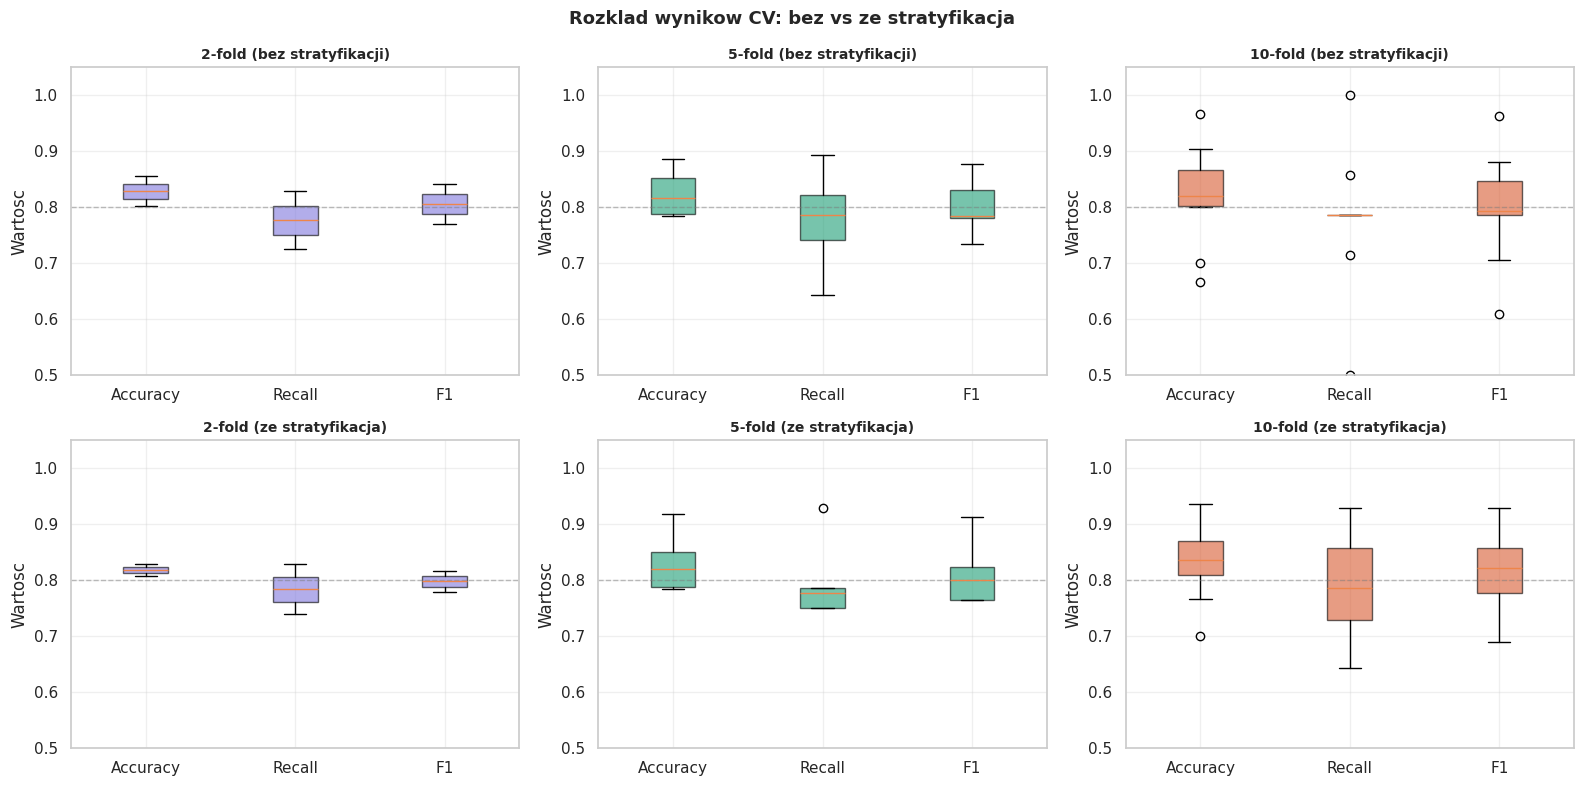

In [22]:
# 6.2 Boxploty wynikow CV
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metryki_plot = ['Accuracy', 'Recall', 'F1']
colors = ['#7F77DD', '#1D9E75', '#D85A30']

for col_idx, k in enumerate([2, 5, 10]):
    for row_idx, (df_src, tytul) in enumerate([(df_cv, 'bez stratyfikacji'),(df_strat, 'ze stratyfikacja')]):
        ax = axes[row_idx][col_idx]
        data_plot = [df_src[(df_src['k']==k)&(df_src['Metryka']==m)].iloc[0]['scores']
                     for m in metryki_plot]

        bp = ax.boxplot(data_plot, tick_labels=metryki_plot, patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor(colors[col_idx])
            patch.set_alpha(0.6)

        ax.set_title(f'{k}-fold ({tytul})', fontweight='bold', fontsize=10)
        ax.set_ylim(0.5, 1.05)
        ax.set_ylabel('Wartosc')
        ax.axhline(0.8, color='gray', lw=1, linestyle='--', alpha=0.5)
        ax.grid(True, alpha=0.3)

plt.suptitle('Rozklad wynikow CV: bez vs ze stratyfikacja', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# WNIOSEK:
#na małych zbiorach danych (~300 próbek) 10-fold bez stratyfikacji jest niestabilny
# bo małe foldy testowe są bardzo wrażliwe na losowy skład. Stratyfikacja jest tu kluczowa — bez
# niej 10-fold wypada gorzej niż 2-fold.
#
# KLUCZOWY WNIOSEK: stratyfikacja jest NIEZBEDNA przy malych zbiorach
#   i duzym k, bo male foldy testowe bez stratyfikacji moga miec zaburzone
#   proporcje klas i dawac bezsensowne wyniki (Recall ~ 0).

---
# Porównanie z notebookiem Kaggle (imakash3011, ~90% accuracy)

Ten sam zbiór — Heart Attack / Cleveland, 303 pacjentów, ten sam cel (czy jest ryzyko zawału).

Porównywałem swój notebook z laboratoriów z: *Heart-Attack-Analysis & Prediction (90.2%)*.

---

## EDA — co ja, co on

**Ja:** wymiary, braki, balans klas, `describe()`, histogramy cech ciągłych, heatmapa korelacji (cp, thalach, oldpeak, exang wychodzą jako ważne).

**On:** to samo w praktyce, ale dużo więcej wykresów — heatmapa na starcie, boxploty przed i po skalowaniu (widać że cholesterol ma inną skalę niż reszta), histogramy tętna osobno dla chorych i zdrowych, scatter thalach vs oldpeak z kolorami klas.

**Kto lepiej:** on pod kątem EDA — szybciej widać sens cech i potrzebę skalowania. U mnie te wnioski też są, ale głównie z liczb i jednej heatmapy, bez tych dodatkowych wizualizacji.

Wykresy kołowe u niego nic nowego nie dają — to samo co `value_counts()`.

---

## Preprocessing

**Ja:** wrzuciłem **cały** `X` do `StandardScaler` — w tym kolumny kategoryczne typu `cp`, `sex`. Traktowałem je jak zwykłe liczby, bez One-Hot. To błąd — skalowanie kategorii nie ma sensu i psuje regresję logistyczną.

**On:** też nie zrobił One-Hot, kategorie zostawił jako cyfry. Ale Min-Max zrobił **tylko** na ciągłych: `trtbps`, `chol`, `thalachh`, `oldpeak`, `age`. Reszty nie ruszał — i to ma sens.

**Kto lepiej:** on. Ja w 4.2 porównywałem skalowanie vs brak skalowania, ale nadal skalowałem wszystko naraz. Powinienem: One-Hot na kategoriach + skalowanie tylko ciągłych.

---

## Modele

**Ja:** tylko regresja logistyczna (+ tuning `C`, L1/L2, `class_weight='balanced'`).

**On:** 7 modeli — Logistic Regression, Decision Tree, Random Forest (300 drzew), XGBoost, KNN, SVM, AdaBoost. Na końcu wykres słupkowy z accuracy.

**Kto lepiej:** on pod wynik na jednym teście. RF, KNN i AdaBoost wyszły ~**90,2%** accuracy, logistyczna ~**83,6%**. Na takim zbiorze drzewa łapią nieliniowości lepiej niż prosta logistyczna.

---

## Ewaluacja — tu jest moja przewaga

**Ja:**
- split 80/20 **ze `stratify=y`** (61 próbek testowych, ten sam % chorych co w całym zbiorze)
- tuning `C` od 0,001 do 100 — widać wpływ na Accuracy, Recall, AUC
- K-Fold CV dla k=2, 5, 10, **z i bez** `StratifiedKFold`, boxploty wyników

**On:**
- zwykły `train_test_split(0.8)` **bez stratify**
- jeden test, jedna liczba accuracy
- parametry „z głowy” (np. `n_estimators=300` w RF) — bez grid search

**Kto lepiej:** ja pod kątem metodologii. Jego 90% to wynik z **jednego** podziału na 61 próbek — może być po prostu łatwiejszy test. Nie wiadomo czy 90% utrzyma się na innym splicie. Moje CV to uśrednia i widać rozrzut (boxploty).

Mój accuracy na hold-out: ~**87%** — niższy niż jego RF, ale bardziej uczciwie zmierzony i powtarzalny.

---

## Podsumowanie

| Obszar | Lepiej |
|--------|--------|
| wizualizacje / EDA | Kaggle |
| preprocessing (co skalować) | Kaggle |
| wiele modeli | Kaggle |
| walidacja, stabilność wyników | mój notebook |
| tuning hiperparametrów | mój notebook |

**Co bym wziął od niego:** boxploty przed/po skali, scattery per klasa, pętlę z Random Forest / XGBoost.

**Co zostawił od siebie:** `stratify`, CV ze stratyfikacją, systematyczny tuning `C`.

**Co poprawić u siebie:** One-Hot na kategoriach, skalowanie tylko ciągłych, dodać choć RF obok logistycznej — ale nadal oceniać przez CV, nie jednym splitem jak on.
